1. dividing the data to bins/sliding windows - 
2. calculating the linear model
    a) add weighting per window to match sample to population
3. creating coef_df (for each linear model summary - coefficients etc.) - run if not using the coef_df created in step9

In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
min_age = 20
max_age = 65

# Options: 'fixed', 'sliding_n_subjects', or 'sliding_n_years'
STRATEGY = 'fixed' 

# manually fixed:
# bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]


# Parameters for 'sliding_n_subjects'
window_subjects = 100 
step_subjects = 50

# Parameters for 'sliding_n_years'
window_years = 5
step_years = 1

# Parameters for 'fixed'
bin_size = 5

# Set to None if you want to run all ROIs
ROI_FILTER = [421, 422]

In [17]:
# helper funciton

import matplotlib.pyplot as plt
import seaborn as sns

def plot_weighting_diagnostic(df, bin_label):
    # Calculate Kish's Effective Sample Size (ESS)
    weights = df['ps_weight'].values
    ess = (weights.sum()**2) / (weights**2).sum()
    n_raw = len(df)
    ess_percent = (ess / n_raw) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    
    # Plot 1: Raw (Unweighted)
    sns.histplot(data=df, x='birth_year', bins=df['birth_year'].nunique(), ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f"Raw Distribution (N={n_raw})")
    axes[0].set_ylabel("Subject Count")
    
    # Plot 2: Weighted
    # Passing weights as .values prevents the "wide-form" ValueError
    sns.histplot(data=df, x='birth_year', bins=df['birth_year'].nunique(), ax=axes[1], color='salmon', 
                 edgecolor='black', weights=weights)
    
    # Add a horizontal line to show what a "perfectly uniform" distribution would look like
    # Total weight (which is N) divided by number of bins
    axes[1].axhline(y=n_raw/df['birth_year'].nunique(), color='red', linestyle='--', alpha=0.5, label='Perfectly Uniform')
    
    axes[1].set_title(f"Weighted (ESS: {ess:.1f} | {ess_percent:.1f}%)")
    axes[1].set_ylabel("Weighted Density")
    
    plt.suptitle(f"Weighting Diagnostic: Age Window {bin_label}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Processing Age Windows:   0%|          | 0/9 [00:00<?, ?it/s]

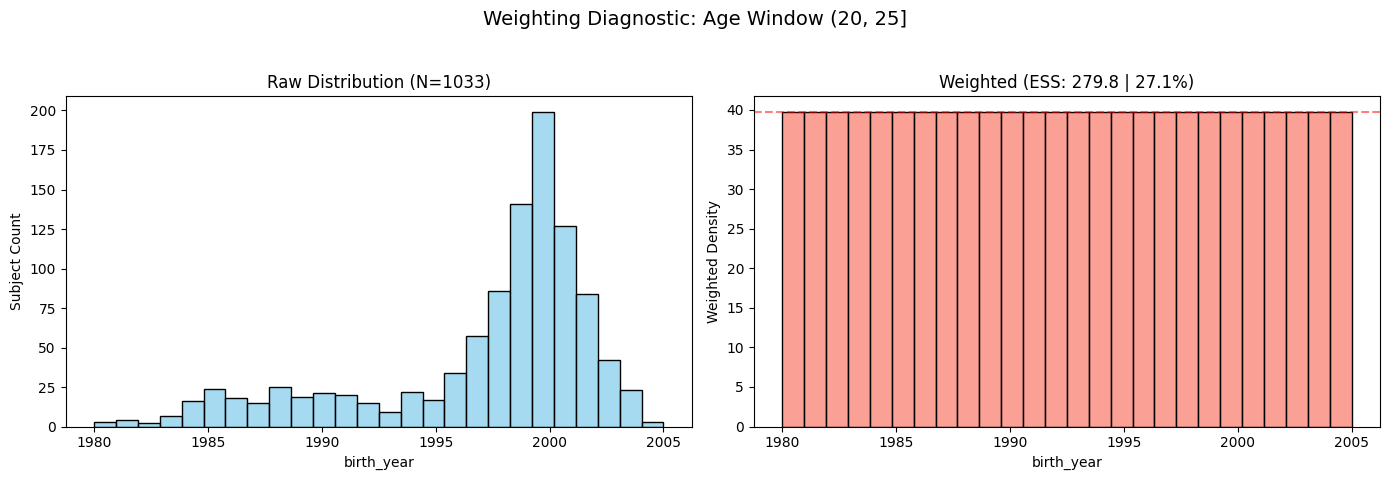

Processing Age Windows:  11%|█         | 1/9 [00:00<00:01,  4.75it/s]

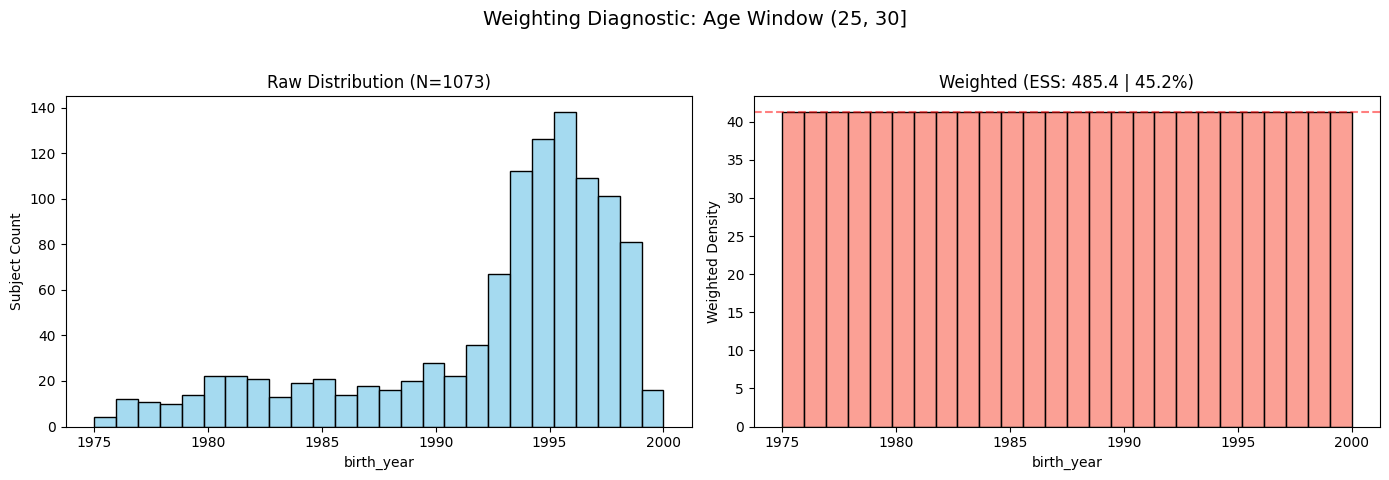

Processing Age Windows:  22%|██▏       | 2/9 [00:00<00:01,  4.88it/s]

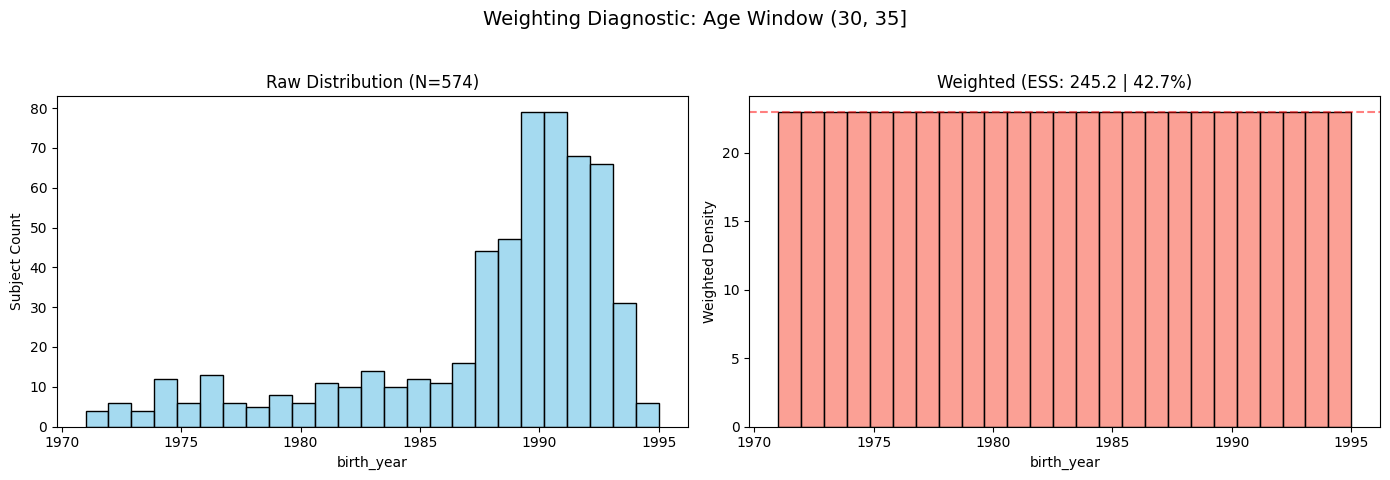

Processing Age Windows:  33%|███▎      | 3/9 [00:00<00:01,  5.08it/s]

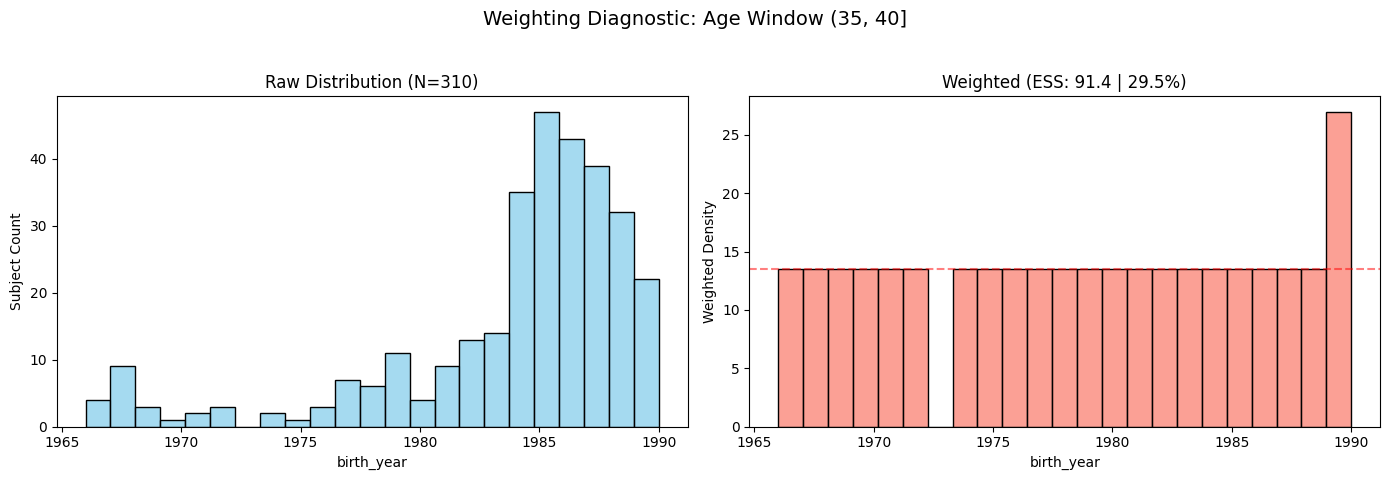

Processing Age Windows:  44%|████▍     | 4/9 [00:00<00:00,  5.37it/s]

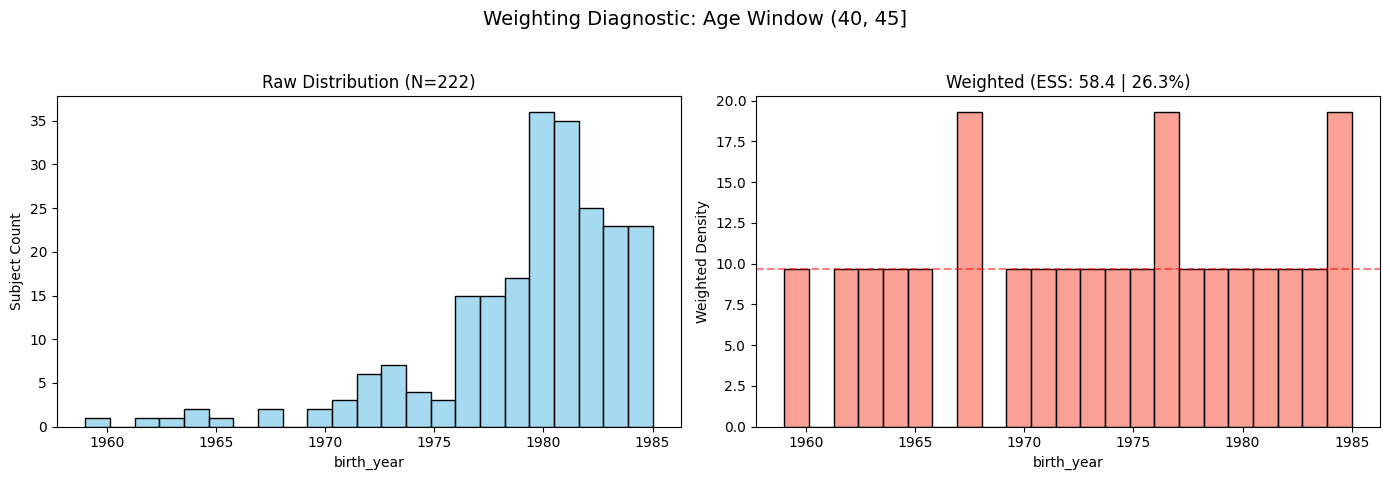

Processing Age Windows:  56%|█████▌    | 5/9 [00:00<00:00,  5.40it/s]

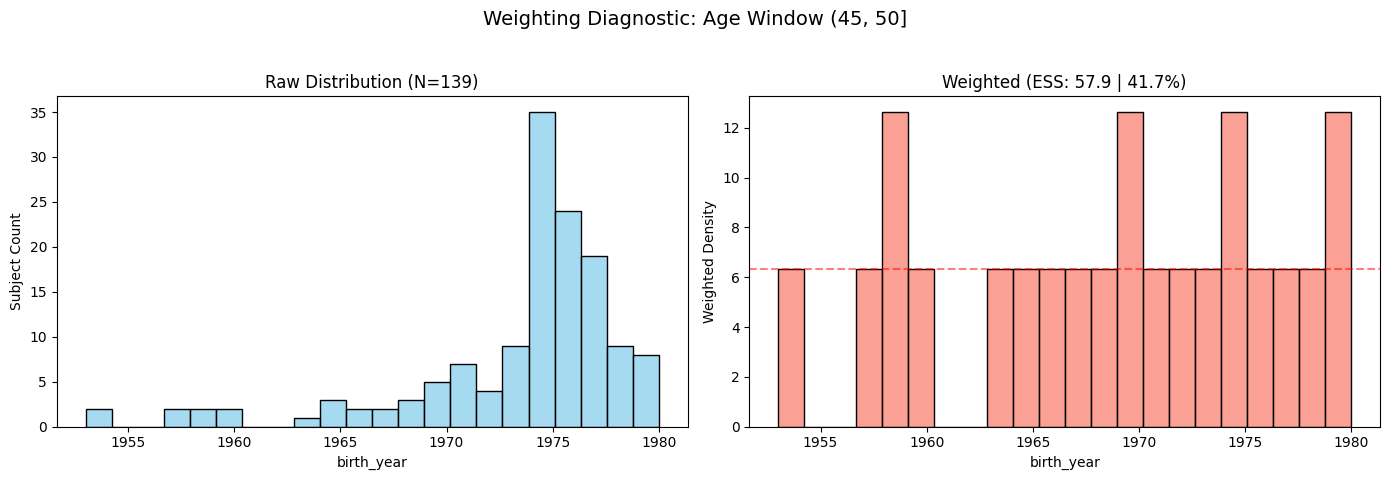

Processing Age Windows:  67%|██████▋   | 6/9 [00:01<00:00,  5.49it/s]

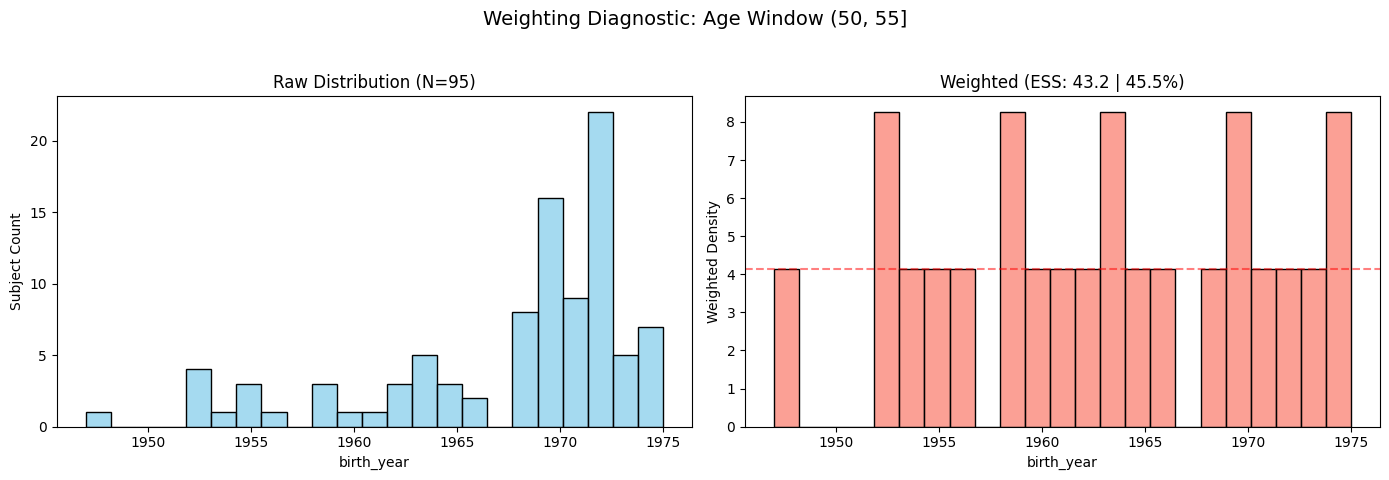

Processing Age Windows:  78%|███████▊  | 7/9 [00:01<00:00,  5.57it/s]

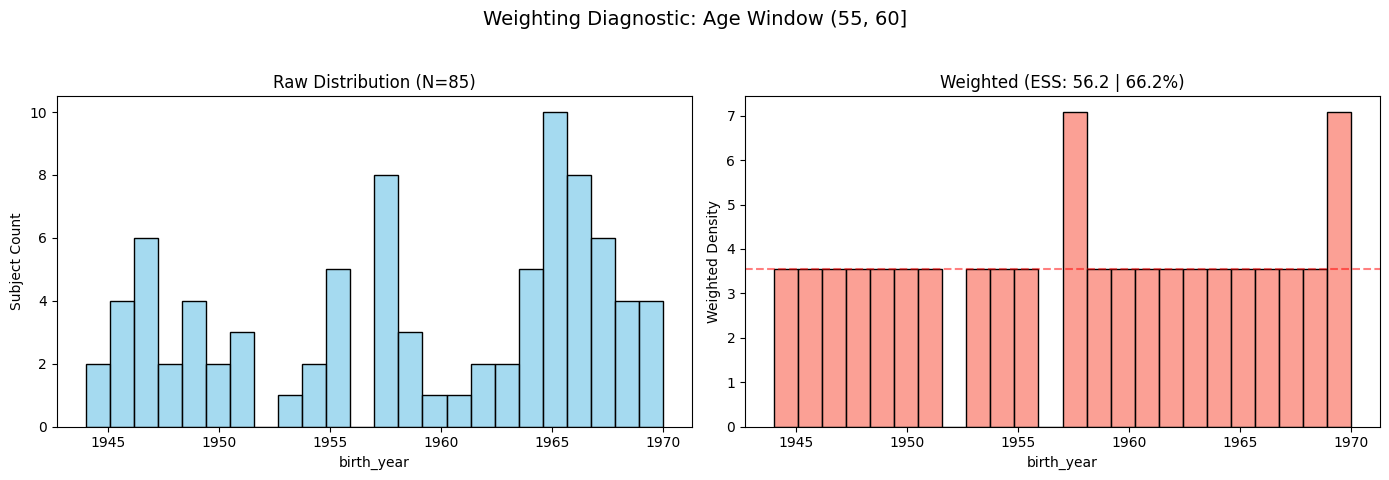

Processing Age Windows:  89%|████████▉ | 8/9 [00:01<00:00,  4.78it/s]

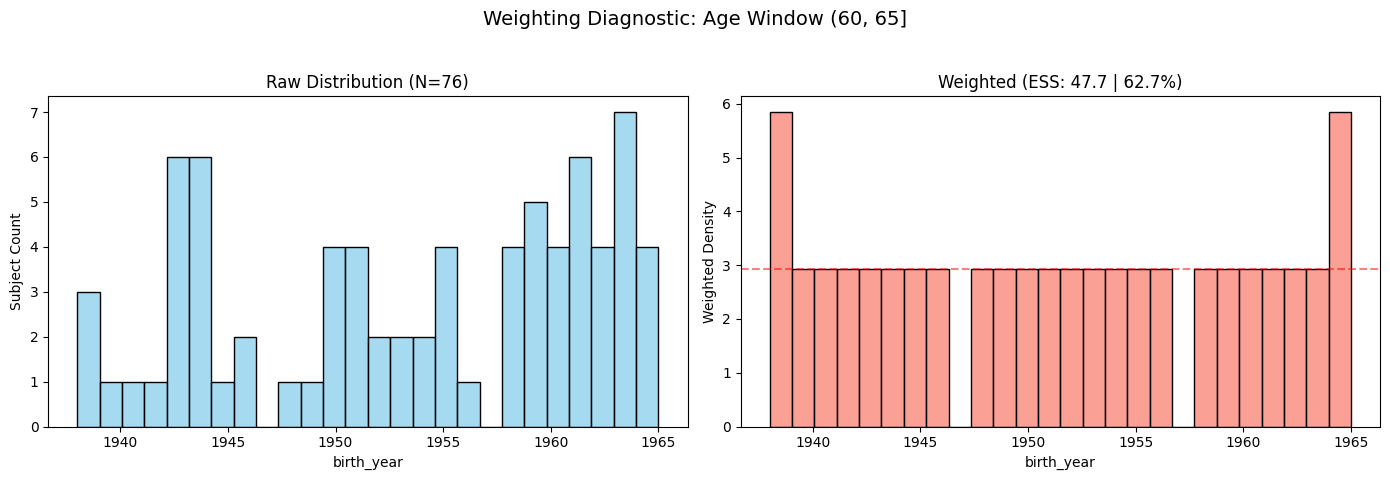

Processing Age Windows: 100%|██████████| 9/9 [00:01<00:00,  5.12it/s]

Analysis Complete.


In [18]:

# --- 1. DATA LOADING & PREP ---
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')].copy()
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')
volumes = volumes[(volumes['age_in_years'] >= min_age) & (volumes['age_in_years'] <= max_age)]
volumes = volumes.dropna(subset=['age_in_years', 'birth_year', 'sex', 'tiv'])
# --- 2. WINDOW DEFINITION ---
mappings = []

# Prepare sorted metadata for sliding strategies
meta = (
    volumes[['session_id', 'age_in_years']]
    .drop_duplicates('session_id')
    .sort_values('age_in_years')
    .reset_index(drop=True)
)

if STRATEGY == 'fixed':
    bins = np.arange(min_age, max_age + bin_size, bin_size)
    volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=bins)
    volumes = volumes.dropna(subset=['age_bin'])

elif STRATEGY == 'sliding_n_subjects':
    session_ids = meta['session_id'].values
    for i in range(0, len(session_ids) - window_subjects + 1, step_subjects):
        subset_ids = session_ids[i : i + window_subjects]
        age_min, age_max = meta.iloc[i]['age_in_years'], meta.iloc[i + window_subjects - 1]['age_in_years']
        label = f"({age_min:.1f}-{age_max:.1f})"
        for sid in subset_ids:
            mappings.append({'session_id': sid, 'age_bin': label})

elif STRATEGY == 'sliding_n_years':
    min_age = meta['age_in_years'].min()
    max_age = meta['age_in_years'].max()
    
    # Iterate through age ranges
    current_start = min_age
    window_idx = 0
    while (current_start + window_years) <= max_age:
        current_end = current_start + window_years
        
        # Find session IDs within this specific age range
        mask = (meta['age_in_years'] >= current_start) & (meta['age_in_years'] < current_end)
        subset_ids = meta.loc[mask, 'session_id'].values
        
        if len(subset_ids) > 0:
            label = f"({current_start:.1f}-{current_end:.1f})"
            for sid in subset_ids:
                mappings.append({'session_id': sid, 'age_bin': label})
        
        current_start += step_years
        window_idx += 1

# Merge back for all sliding strategies
if 'sliding' in STRATEGY:
    map_df = pd.DataFrame(mappings)
    volumes = volumes.merge(map_df, on='session_id')

# --- 3. ANALYSIS ---
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
results = []

# Filtering by ROI list if provided
if ROI_FILTER is not None:
    volumes = volumes[volumes['region_label'].isin(ROI_FILTER)]

# Group by age_bin first to calculate weights once per window
for bin_label, df_bin in tqdm(volumes.groupby('age_bin', observed=True), desc="Processing Age Windows"):
    
    # 1. Get unique subjects for this age window
    # We do this once for the whole bin because birth_year is subject-level
    df_window_subjects = df_bin.drop_duplicates(subset=['subject_id'], keep='first').copy()
    
    if len(df_window_subjects) < 20:
        continue

    # 2. Calculate Propensity Weights for the window
    counts = df_window_subjects['birth_year'].value_counts()
    weights_map = 1.0 / counts
    df_window_subjects['ps_weight'] = df_window_subjects['birth_year'].map(weights_map)
    df_window_subjects['ps_weight'] *= (len(df_window_subjects) / df_window_subjects['ps_weight'].sum())

    # --- NEW: Calculate ESS for storage ---
    current_ess = (df_window_subjects['ps_weight'].sum()**2) / (df_window_subjects['ps_weight']**2).sum()

    # 3. Diagnostic Plot (Only once per age window)
    plot_weighting_diagnostic(df_window_subjects, bin_label)

    # 4. Create a mapping of subject_id -> weight to apply to all ROIs in this bin
    weight_lookup = df_window_subjects.set_index('subject_id')['ps_weight']

    # 5. Process each ROI within this window
    for roi, df_roi in df_bin.groupby('region_label', observed=True):
        # Apply the pre-calculated weights to this ROI's data
        # (This handles the case where you might have multiple sessions/scans per subject)
        df_roi = df_roi.drop_duplicates(subset=['subject_id'], keep='first').copy()
        df_roi['ps_weight'] = df_roi['subject_id'].map(weight_lookup)
        
        try:
            model = smf.wls(
                'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years', 
                data=df_roi,
                weights=df_roi['ps_weight']
            ).fit()
            
            for var in model.params.index:
                results.append({
                    'age_bin': bin_label,
                    'region_label': roi,
                    'variable': var,
                    'coef': model.params[var],
                    't': model.tvalues[var],
                    'p': model.pvalues[var],
                    'n_subjects': len(df_roi),
                    'ess': current_ess
                })
        except:
            continue

# --- 4. POST-PROCESSING ---
coef_df = pd.DataFrame(results)

# Add Atlas names
coef_df = coef_df.merge(atlas_csv[['index', 'name']], left_on='region_label', right_on='index', how='left')
coef_df.rename(columns={'name': 'region_name'}, inplace=True)

# Multiple Comparison Correction (FDR) per window for 'birth_year'
final_rows = []
for label, group in coef_df.groupby('age_bin'):
    mask = group['variable'] == 'birth_year'
    if mask.any():
        _, fdr_p, _, _ = multipletests(group.loc[mask, 'p'], method='fdr_bh')
        group.loc[mask, 'fdr_p'] = fdr_p
    final_rows.append(group)

coef_df = pd.concat(final_rows)

# --- 5. SAVE ---
suffix = f"sliding_ws{window_subjects}_ss{step_subjects}" if STRATEGY == 'sliding_n_subjects' else f"sliding_wy{window_years}_sy{step_years}" if STRATEGY == 'sliding_n_years' else f"fixed_bin{bin_size}"

print("Analysis Complete.")

In [19]:
# coef_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_{suffix}.csv", index=False)
# print(f"Saved coefficients to /home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_{suffix}.csv")


# QA - comparing the result here to step9

In [20]:
# # compare the coef_df that created here to the one created in step9
# step9_coef_df = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_age_bins_size_5.csv")

# step12_coef_df = coef_df.copy()  # Use the coef_df created in this step


# # remove the columns from step12_coef_df: n_subjects, index
# step12_coef_df = step12_coef_df.drop(columns=['n_subjects', 'index'], errors='ignore')


# # Define the specific interval to remove
# bin_to_remove = pd.Interval(15, 20, closed='right')

# # Filter it out
# step12_coef_df = step12_coef_df[~step12_coef_df['bin'].isin([bin_to_remove])]


# # order the columns 
# step12_coef_df = step12_coef_df[[ 'bin', 'region_label', 'region_name', 'variable', 'coef', 't', 'p', 'fdr_p']]
# step9_coef_df = step9_coef_df[['age_bin', 'region_label', 'region_name', 'variable', 'coef', 't', 'p', 'fdr_p']]

# # order both by region_label, region_name, variable
# step9_coef_df = step9_coef_df.sort_values(['region_label', 'region_name', 'variable'])
# step12_coef_df = step12_coef_df.sort_values(['region_label', 'region_name', 'variable'])



# print(f"are they the same? {step9_coef_df.equals(step12_coef_df)}")

# print(f"age bins: step9: {step9_coef_df['age_bin'].unique()}, step12: {step12_coef_df['bin'].unique()}")